[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sibbirhossain/finguard-xai/blob/main/notebooks/08_adversarial_robustness.ipynb)

# 08 · Adversarial Robustness: When Fraudsters Fight Back

**Question:** *once a graph-based detector is deployed, criminals adapt. How much does detection degrade, and what limits the damage?*

**Protocol.** The system is trained on clean history and then frozen. Only fraud-ring activity in the *future* test window is modified, simulating attackers who adapt after deployment. Each attack is repeated over 5 seeds (`src/experiments/robustness.py`).

| Attack | What the attacker does |
|---|---|
| Device dispersion | Every ring transaction uses a brand-new device and IP, erasing shared-infrastructure links |
| Camouflage | Before each fraudulent purchase, the ring card makes two ordinary purchases at popular merchants from its usual device, diluting its neighborhood |
| Combined | Both at once |

In [1]:
# --- Setup: works in Google Colab and inside a local clone ---
import os, sys, subprocess, warnings
warnings.filterwarnings("ignore")
if os.path.exists("../src/models"):
    os.chdir("..")
elif not os.path.exists("src/models"):
    if not os.path.exists("finguard-xai"):
        subprocess.run(["git", "clone", "-q", "https://github.com/sibbirhossain/finguard-xai.git"], check=True)
    os.chdir("finguard-xai")
try:
    import torch_geometric  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch_geometric"], check=True)
sys.path.insert(0, os.getcwd())
import warnings; warnings.filterwarnings("ignore")
import json, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("ready:", os.getcwd())

ready: /home/claude/finguard-xai


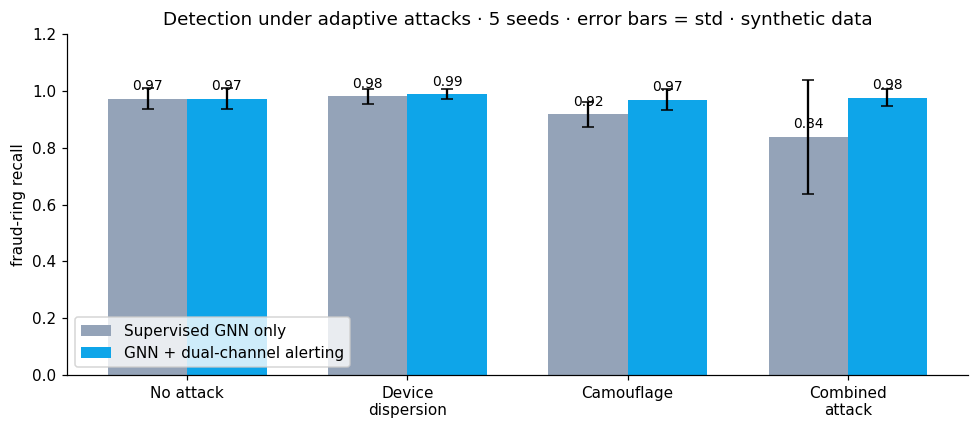

In [2]:
R = json.loads(open("reports/robustness/ROBUSTNESS.json").read())
attacks = ["none", "device_dispersion", "camouflage", "combined"]
labels = ["No attack", "Device\ndispersion", "Camouflage", "Combined\nattack"]
x = np.arange(4); w = .36
g = [R[a]["gnn_ring_recall"] for a in attacks]; d = [R[a]["dual_ring_recall"] for a in attacks]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, [v[0] for v in g], w, yerr=[v[1] for v in g], capsize=4, label="Supervised GNN only", color="#94a3b8")
ax.bar(x + w/2, [v[0] for v in d], w, yerr=[v[1] for v in d], capsize=4, label="GNN + dual-channel alerting", color="#0ea5e9")
for i in range(4):
    ax.text(i - w/2, g[i][0] + .03, f"{g[i][0]:.2f}", ha="center", fontsize=9); ax.text(i + w/2, d[i][0] + .03, f"{d[i][0]:.2f}", ha="center", fontsize=9)
ax.set_xticks(x, labels); ax.set_ylim(0, 1.2); ax.set_ylabel("fraud-ring recall"); ax.legend(loc="lower left")
ax.set_title("Detection under adaptive attacks · 5 seeds · error bars = std · synthetic data"); plt.tight_layout(); plt.show()

In [3]:
import pandas as pd
pd.DataFrame({a: {"ring recall (GNN)": R[a]["gnn_ring_recall"][0], "ring recall (dual)": R[a]["dual_ring_recall"][0],
                  "FPR (GNN)": R[a]["gnn_fpr"][0], "FPR (dual)": R[a]["dual_fpr"][0]} for a in attacks}).T.round(4)

,ring recall (GNN),ring recall (dual),FPR (GNN),FPR (dual)
none,0.9727,0.9727,0.0060,0.0128
device_dispersion,0.9806,0.9884,0.0059,0.0136
camouflage,0.9178,0.9684,0.0066,0.0143
combined,0.8387,0.9758,0.0066,0.0144


### Findings
1. **Device dispersion alone did not evade detection.** Brand-new devices with no history are themselves suspicious, and the rings still converge on the same cash-out merchants. The model does not depend on a single relationship type.
2. **Camouflage is the more effective attack.** Adding benign-looking edges lowered the supervised GNN's ring recall, and combining both attacks made it unstable across seeds (high variance).
3. **The dual-channel design limits the damage.** The novelty channel kept ring recall near its no-attack level in every scenario.
4. **Stated cost.** The dual channel roughly doubles the false-positive rate (~1.4% vs ~0.6% of legitimate traffic). The budget is configurable (`novelty_fpr`).

**Limitations.** These are simulated attackers on synthetic data with a small number of ring transactions per test window (32–125). Adaptive attackers with knowledge of the model (white-box) are not yet evaluated.